In [10]:
# import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import torch
import os
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set_style("whitegrid")
from model import *
from noise import *
from torch.utils.data import DataLoader, Dataset

torch.set_default_dtype(torch.float64)

In [11]:
#Read data from .csv file
approx_sol = pd.read_csv('eg2_sol.csv', sep=',')
approx_solut = approx_sol.to_numpy()

#Data properties
components = 1 #spatial dimensions
deltat = 0.04
t = np.arange(0, 1, deltat)
time_steps = len(t)
n_initial_cond = approx_solut.shape[0] #number of initial conditions for solutions

#Read True RHS from .csv file
true_der = pd.read_csv('eg2_true_RHS.csv', sep=',')
true_der = true_der.to_numpy()

#Read Difference Quotients from .csv file
Diff_quot = pd.read_csv('eg2_app_RHS.csv', sep=',')
Diff_quot = Diff_quot.to_numpy()

# Add noise
noise_level = 0.1
approx_solut_noise, DQ_noise = add_noise(approx_solut, t, deltat, noise_level)

# Append t and x(t)
t_copy = np.tile(t, n_initial_cond).reshape(-1,1)
x_t = approx_solut_noise.reshape(-1,1) 
inputs = np.append(t_copy, x_t, axis=1)
targets = DQ_noise[:,1:-1].reshape(-1,1)

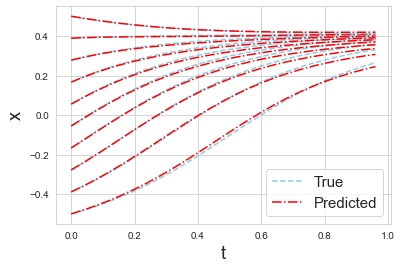

In [12]:
# Setup Parameters
N = 50
sigma = 1
reg_param = 0.00001

W = np.random.randn(2,N) / sigma
b = np.random.uniform(0, 2*np.pi, size=(N,))
A = np.cos(inputs @ W + b) * np.sqrt(2/N)
c = np.linalg.solve(A.T@A + reg_param * np.diag(np.linalg.norm(W,axis=0)), A.T@targets)

# approximate the solution
def g(x,t):
    A = np.cos(W[0] * t + W[1] * x + b)
    return np.sum(A * c.reshape(-1) * np.sqrt(2/N))

def fun(x, t):
    return np.cos(3*x) + x**3 - x

# time stamps
deltat = 0.04
t = np.arange(0, 1, deltat)
# 200 initial conditions
x_0 = np.linspace(-0.5,0.5,10)

for i in x_0:

    # solve
    sol = odeint(fun, i, t)
    sol_app = odeint(g, i, t)

    # transpose the solution, each row is a trajectory
    data = sol.T
    data1 = sol_app.T
    
    plt.plot(t, data.reshape(-1), '--', c='skyblue')
    plt.plot(t, data1.reshape(-1), '-.', c='red')

plt.legend(['True', 'Predicted'], fontsize=15 )
#plt.xticks(size=15)
#plt.yticks(size=15)
plt.xlabel('t', size=18)
plt.ylabel('x', size=18)
plt.savefig('Eg2_sol_noise1.pdf', bbox_inches = 'tight')

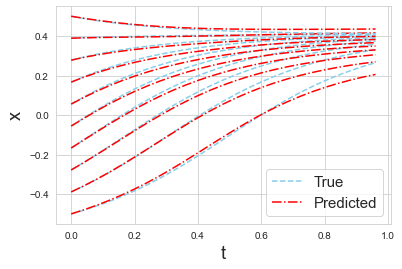

In [13]:
#Read data from .csv file
approx_sol = pd.read_csv('eg2_sol.csv', sep=',')
approx_solut = approx_sol.to_numpy()

#Data properties
components = 1 #spatial dimensions
deltat = 0.04
t = np.arange(0, 1, deltat)
time_steps = len(t)
n_initial_cond = approx_solut.shape[0] #number of initial conditions for solutions

#Read True RHS from .csv file
true_der = pd.read_csv('eg2_true_RHS.csv', sep=',')
true_der = true_der.to_numpy()

#Read Difference Quotients from .csv file
Diff_quot = pd.read_csv('eg2_app_RHS.csv', sep=',')
Diff_quot = Diff_quot.to_numpy()

# Add noise
noise_level = np.sqrt(0.05)
approx_solut_noise, DQ_noise = add_noise(approx_solut, t, deltat, noise_level)

# Append t and x(t)
t_copy = np.tile(t, n_initial_cond).reshape(-1,1)
x_t = approx_solut_noise.reshape(-1,1) 
inputs = np.append(t_copy, x_t, axis=1)
targets = DQ_noise[:,1:-1].reshape(-1,1)

# Setup Parameters
N = 50
sigma = 1
reg_param = 0.00001

W = np.random.randn(2,N) / sigma
b = np.random.uniform(0, 2*np.pi, size=(N,))
A = np.cos(inputs @ W + b) * np.sqrt(2/N)
c = np.linalg.solve(A.T@A + reg_param * np.diag(np.linalg.norm(W,axis=0)), A.T@targets)

# approximate the solution
def g(x,t):
    A = np.cos(W[0] * t + W[1] * x + b)
    return np.sum(A * c.reshape(-1) * np.sqrt(2/N))

def fun(x, t):
    return np.cos(3*x) + x**3 - x

# time stamps
deltat = 0.04
t = np.arange(0, 1, deltat)
# 200 initial conditions
x_0 = np.linspace(-0.5,0.5,10)

for i in x_0:

    # solve
    sol = odeint(fun, i, t)
    sol_app = odeint(g, i, t)

    # transpose the solution, each row is a trajectory
    data = sol.T
    data1 = sol_app.T
    
    plt.plot(t, data.reshape(-1), '--', c='skyblue')
    plt.plot(t, data1.reshape(-1), '-.', c='red')

plt.legend(['True', 'Predicted'], fontsize=15 )
#plt.xticks(size=15)
#plt.yticks(size=15)
plt.xlabel('t', size=18)
plt.ylabel('x', size=18)
plt.savefig('Eg2_sol_noise2.pdf', bbox_inches = 'tight')